# How to generate a utility report?

Assume that the synthetic data is already generated \
Based on the Wisconsin Breast Cancer Dataset

In [1]:
# Standard library
import sys

sys.path.append("..")

# 3rd party packages
import pandas as pd

# Local packages
import config
import utils.draw
from metrics.utility.report import Report

## Load the real and synthetic WBCD datasets

In [2]:
df_real = {}
df_real["train"] = pd.read_csv("../data/" + config.WBCD_DATASET_TRAIN_FILEPATH.stem + ".csv")
df_real["test"] = pd.read_csv("../data/" + config.WBCD_DATASET_TEST_FILEPATH.stem + ".csv")
df_real["train"].shape

(359, 10)

### Choose the synthetic dataset

In [3]:
df_synth = {}  # generated by Synthpop ordered here
df_synth["train"] = pd.read_csv("../results/data/2023-07-31_Synthpop_359samples.csv")
df_synth["test"] = pd.read_csv("../results/data/2023-07-31_Synthpop_90samples.csv")
df_synth["test"].shape

(90, 10)

## Configure the metadata dictionary

### The continuous and categorical variables need to be specified, as well as the variable to predict for the future learning task

In [4]:
metadata = {
    "continuous": [
        "Clump_Thickness",
        "Uniformity_of_Cell_Size",
        "Uniformity_of_Cell_Shape",
        "Marginal_Adhesion",
        "Single_Epithelial_Cell_Size",
        "Bland_Chromatin",
        "Normal_Nucleoli",
        "Mitoses",
        "Bare_Nuclei",
    ],
    "categorical": ["Class"],
    "variable_to_predict": "Class",
}

## Compare the distributions

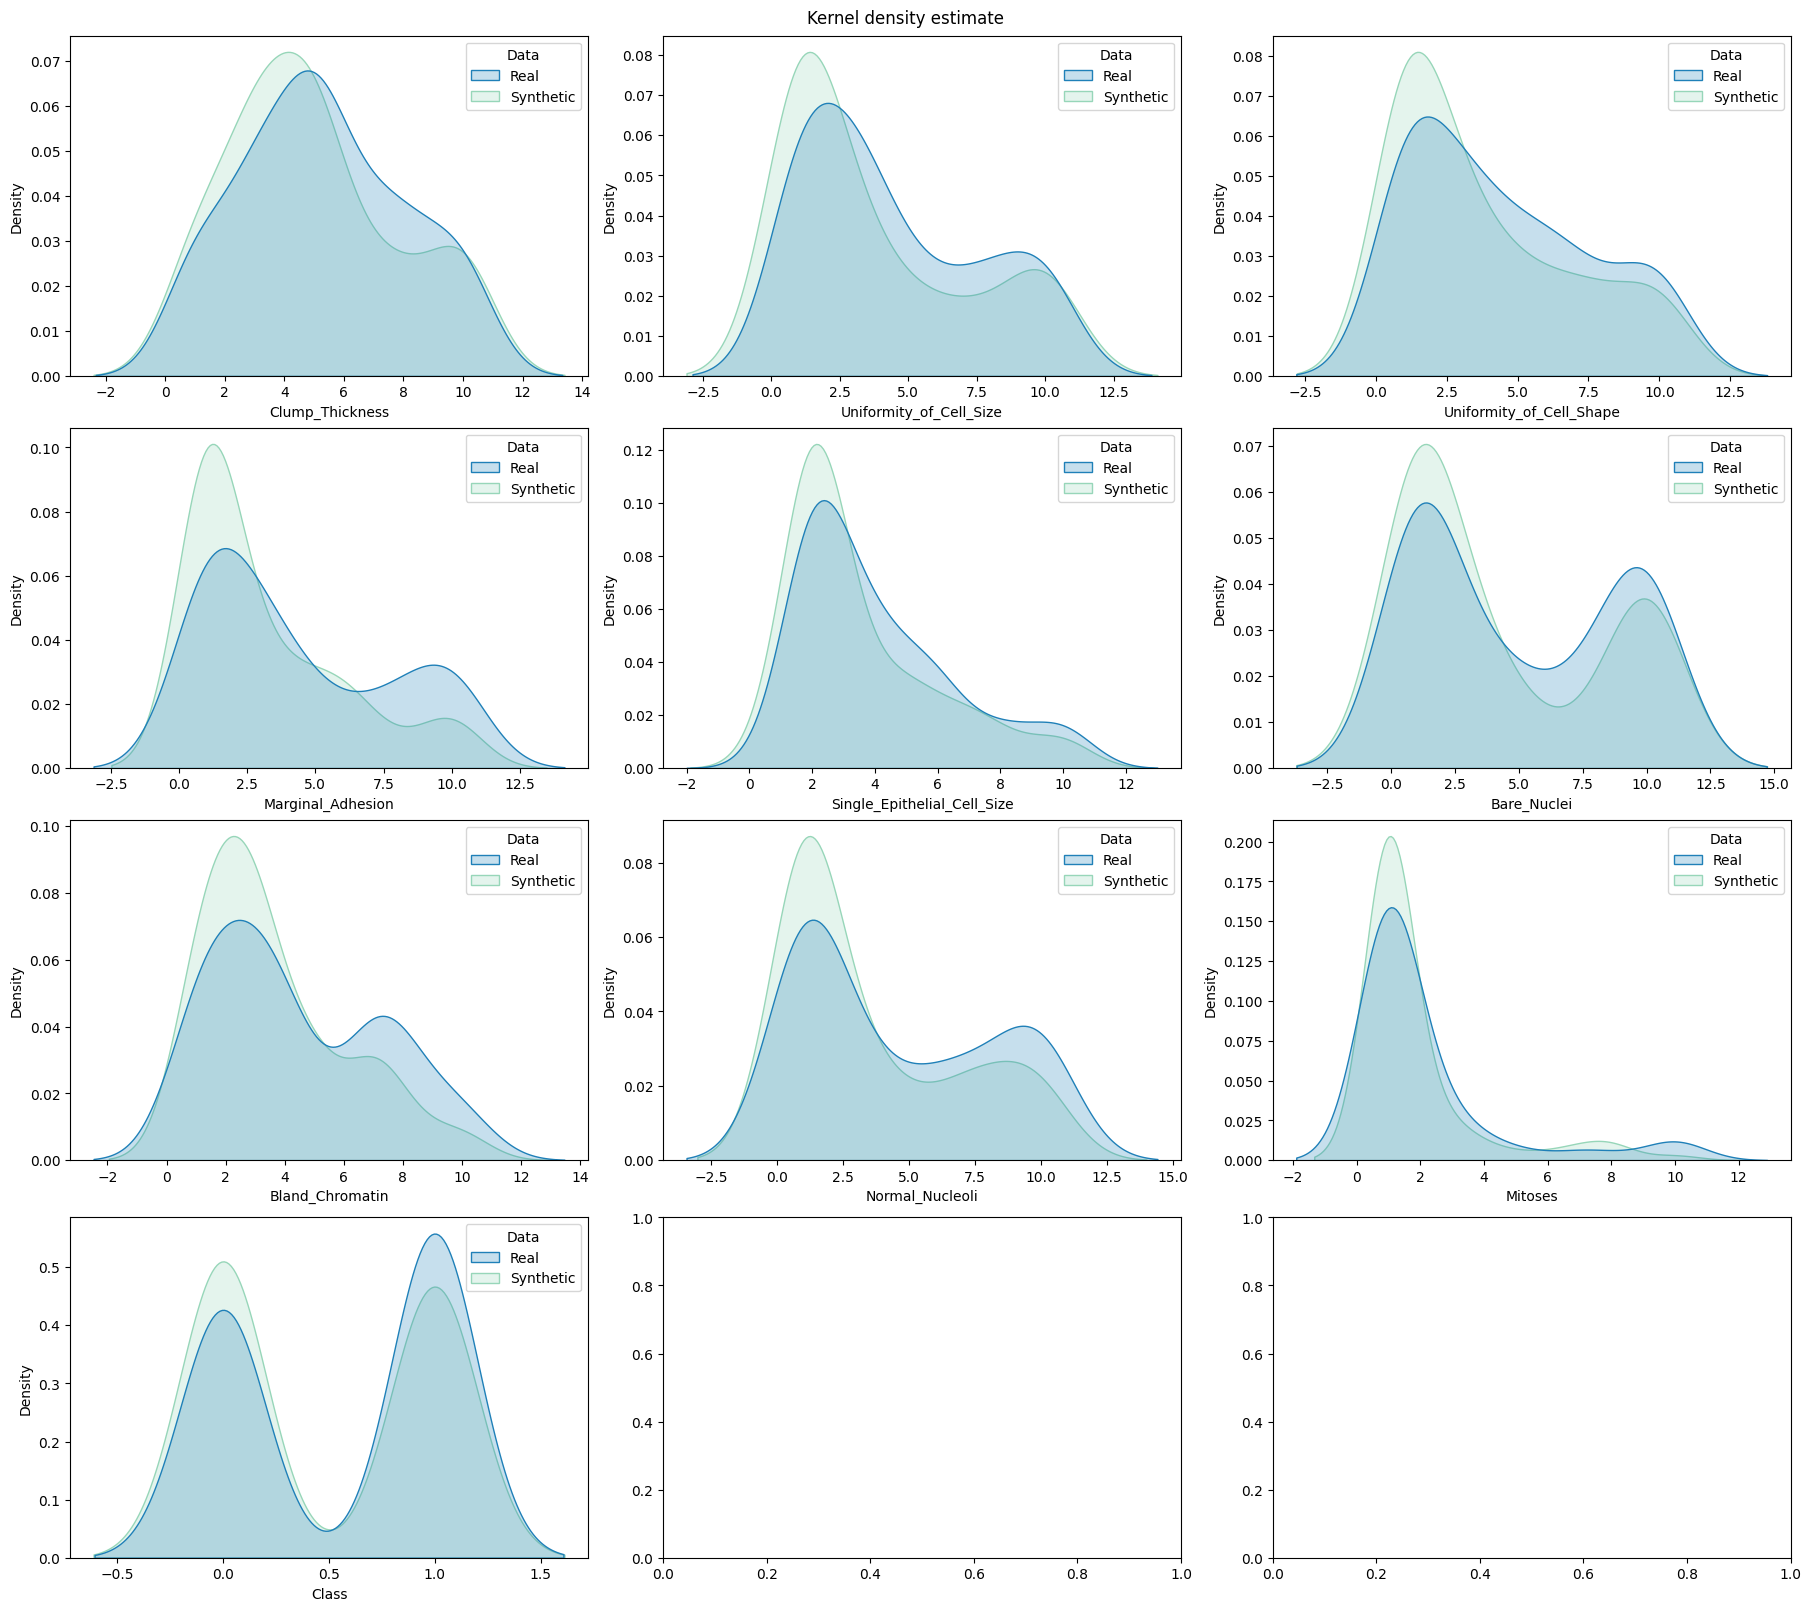

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(  # manually set number of cols/rows
    nrows=4, ncols=3, squeeze=0, figsize=(18, 16), layout="constrained"
)
axes = axes.reshape(-1)
utils.draw.kde_plot_hue_plot_per_col(
    df=df_real["test"],
    df_nested=df_synth["test"],
    original_name="Real",
    nested_name="Synthetic",
    hue_name="Data",
    title="Kernel density estimate",
    axes=axes,
)

## Generate the utility report

Some metrics will not be computed since the only categorical variable is the variable to predict 

### First option: Create and compute the full utility report - it takes some time

In [6]:
report = Report(
    dataset_name="Wisconsin Breast Cancer Dataset",
    df_real=df_real,
    df_synthetic=df_synth,
    metadata=metadata,
    cross_learning=True,  # not parallelized yet, can be set to False if the computation is too slow. See the use_gpu flag to accelerate the computation
    num_repeat=3,  # for the metrics relying on predictions
    use_gpu=True,  # run the learning tasks on the GPU
    alpha=0.05,  # for the pairwise chi-square metric
    figsize=(8, 6),  # will be automatically adjusted for larger or longer figures
    random_state=0,  # for reproducibility purposes
)

In [7]:
report.compute()

#### Get the summary report as a pandas dataframe

In [8]:
report.specification()

----- Wisconsin Breast Cancer Dataset -----
Contains:
    - 359 instances in the train set,
    - 90 instances in the test set,
    - 10 variables, 9 continuous and 1 categorical.


In [9]:
df_summary = report.summary()

In [10]:
by = ["name", "objective", "min", "max"]
df_summary.groupby(by).apply(lambda x: x.drop(by, axis=1).reset_index(drop=True))

submetric  \
name                                          objective min max                                  
Categorical Consistency                       max       0   1.0 0                 within_ratio   
Categorical Statistics                        max       0   1.0 0             support_coverage   
                                                                1           frequency_coverage   
Classification                                min       0   1.0 0              diff_real_synth   
Continuous Consistency                        max       0   1.0 0                 within_ratio   
Continuous Statistics                         min       0   inf 0           median_l1_distance   
                                                                1              iqr_l1_distance   
Cross Classification                          min       0   1.0 0              diff_real_synth   
Cross Regression                              min       0   inf 0              diff_real_synth   
Distinguishability                            min       0   1.0 0               prediction_mse   
                                                                1          prediction_mse_real   
                                                                2         prediction_mse_synth   
                                                                3               prediction_auc   
FScore                                        min       0   inf 0                 diff_f_score   
Feature Importance                            min       0   inf 0  diff_permutation_importance   
Hellinger Categorical Univariate Distance     min       0   1.0 0           hellinger_distance   
Hellinger Continuous Univariate Distance      min       0   1.0 0           hellinger_distance   
KL Divergence Categorical Univariate Distance min       0   inf 0                kl_divergence   
KL Divergence Continuous Univariate Distance  min       0   inf 0                kl_divergence   
Pairwise Correlation Difference               min       0   inf 0                         norm   

                                                                      value  
name                                          objective min max              
Categorical Consistency                       max       0   1.0 0  1.000000  
Categorical Statistics                        max       0   1.0 0  1.000000  
                                                                1  0.958217  
Classification                                min       0   1.0 0  0.001508  
Continuous Consistency                        max       0   1.0 0  1.000000  
Continuous Statistics                         min       0   inf 0  0.012346  
                                                                1  0.061728  
Cross Classification                          min       0   1.0 0  0.001508  
Cross Regression                              min       0   inf 0  0.754246  
Distinguishability                            min       0   1.0 0  0.160868  
                                                                1  0.166074  
                                                                2  0.155661  
                                                                3  0.050988  
FScore                                        min       0   inf 0  0.241306  
Feature Importance                            min       0   inf 0  0.015741  
Hellinger Categorical Univariate Distance     min       0   1.0 0  0.029553  
Hellinger Continuous Univariate Distance      min       0   1.0 0  0.062990  
KL Divergence Categorical Univariate Distance min       0   inf 0  0.003493  
KL Divergence Continuous Univariate Distance  min       0   inf 0  0.015213  
Pairwise Correlation Difference               min       0   inf 0  0.316965

#### Display the detailed report

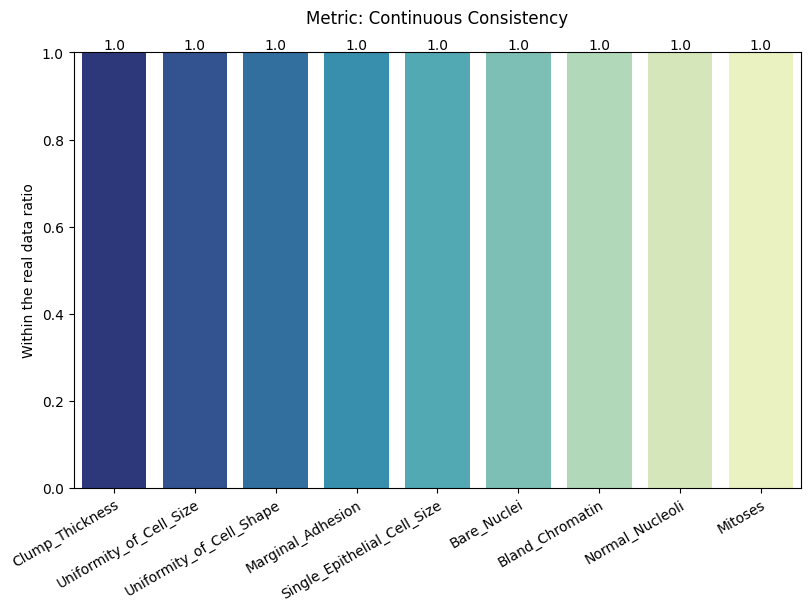

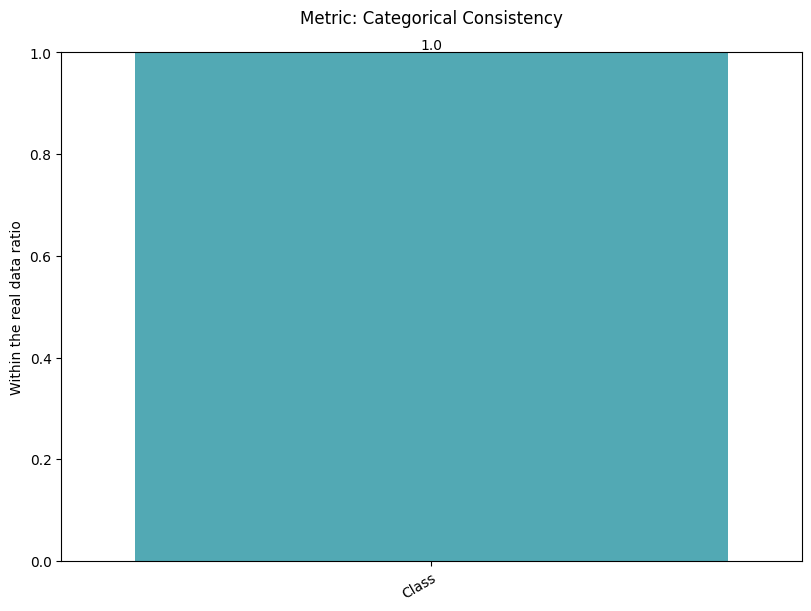

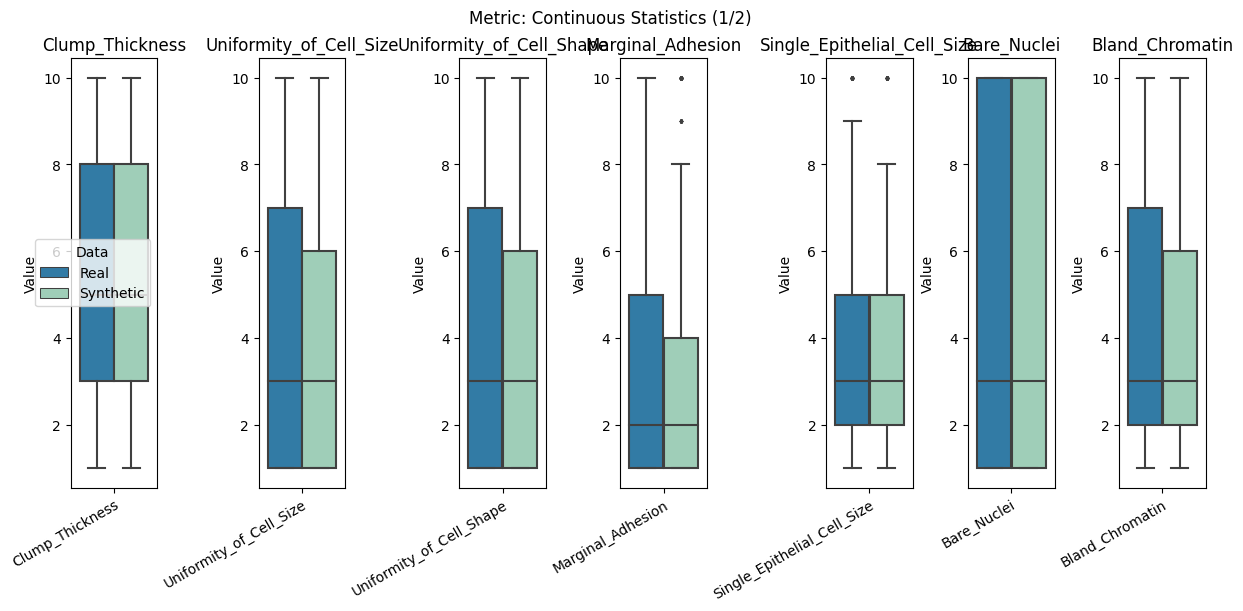

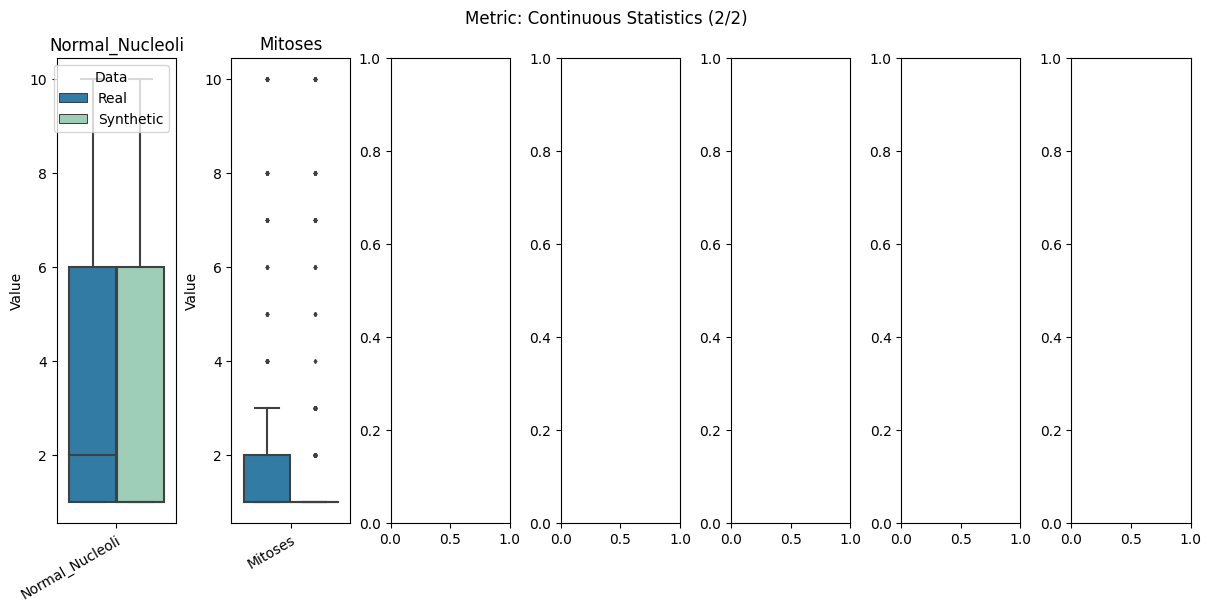

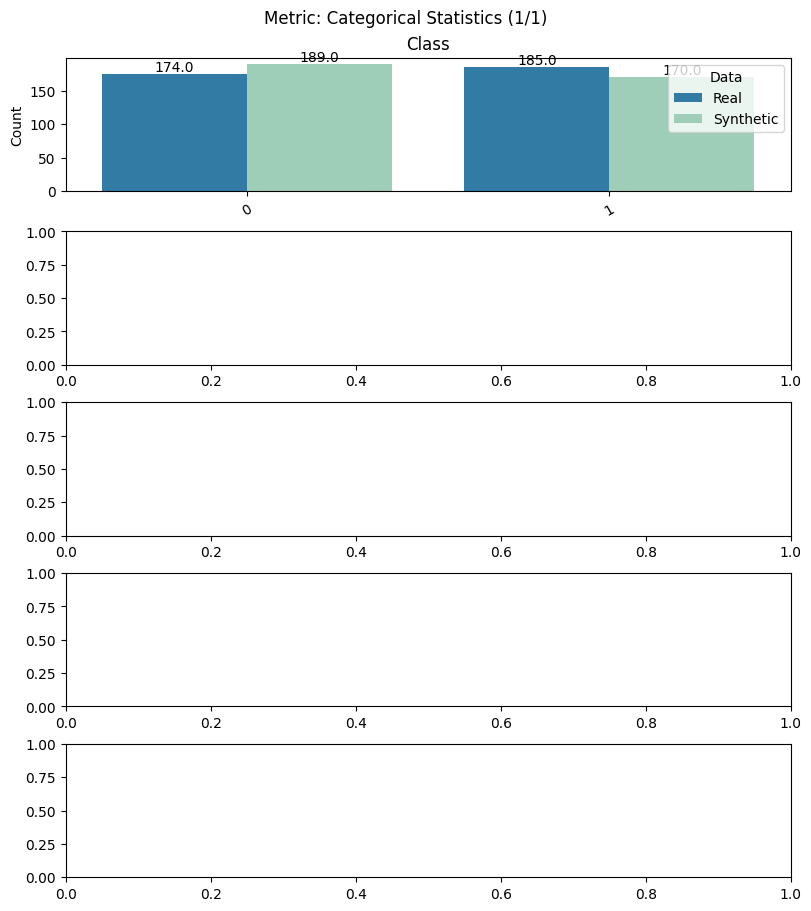

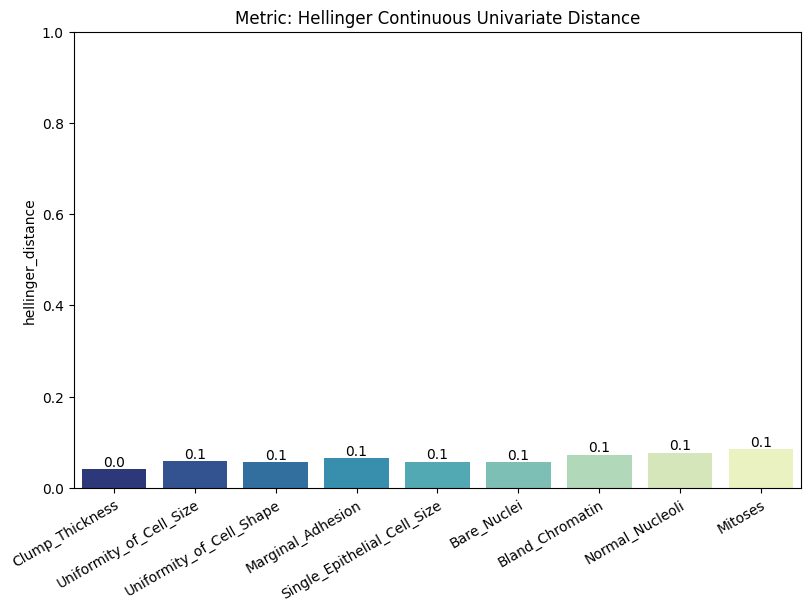

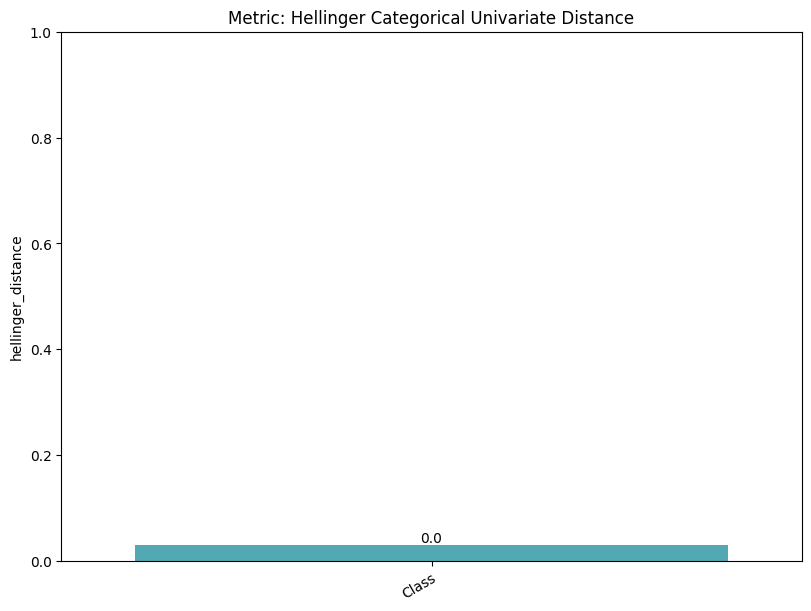

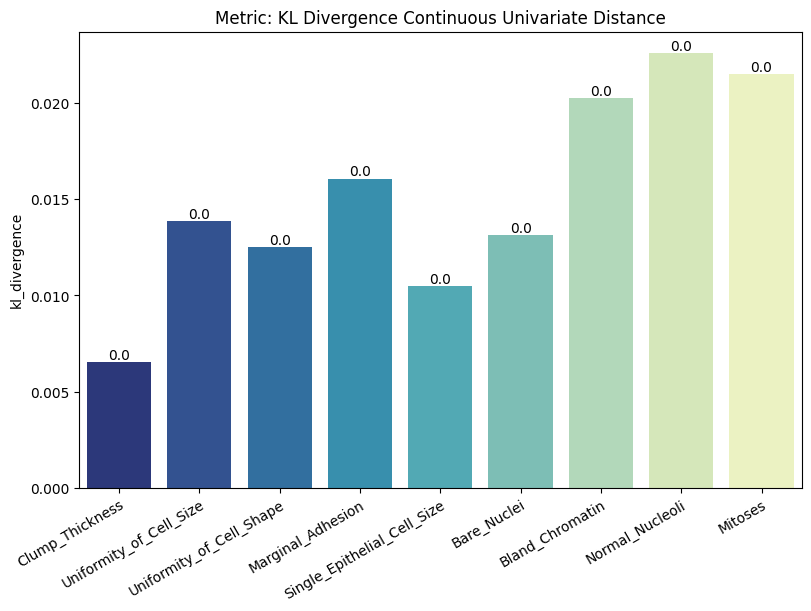

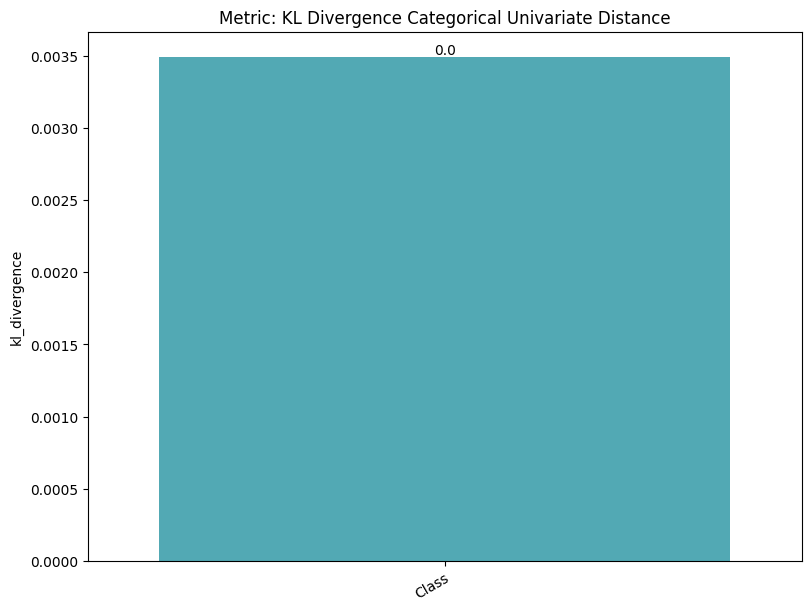

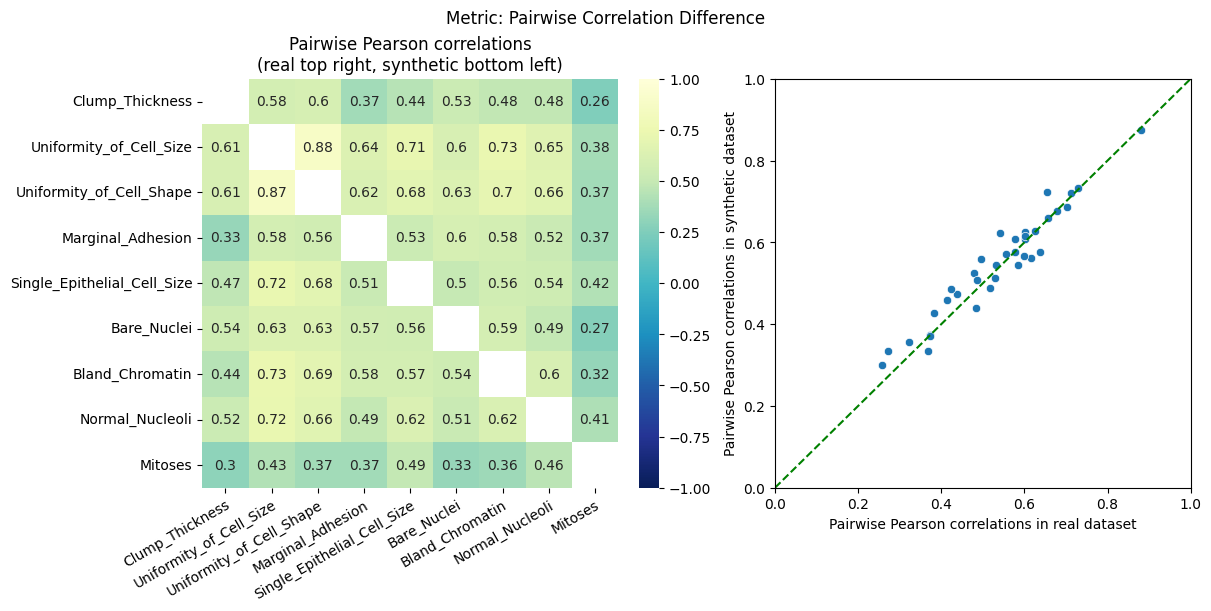

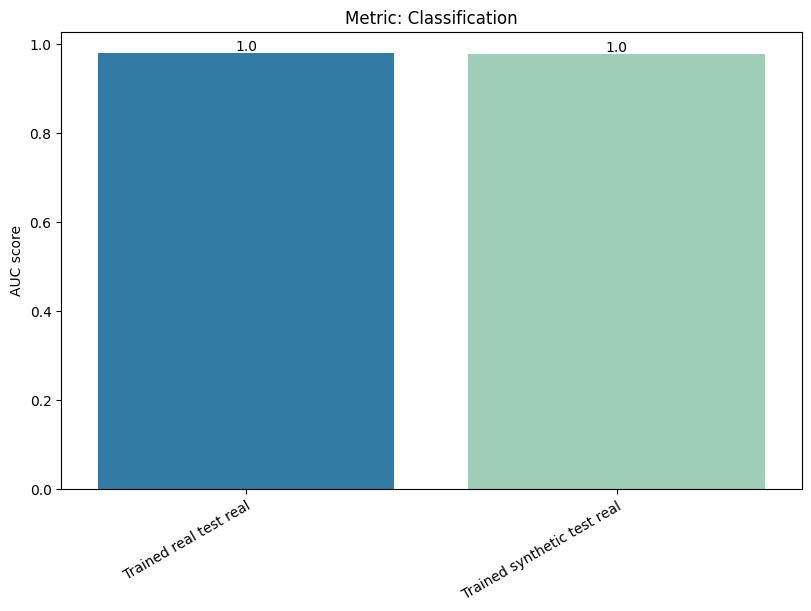

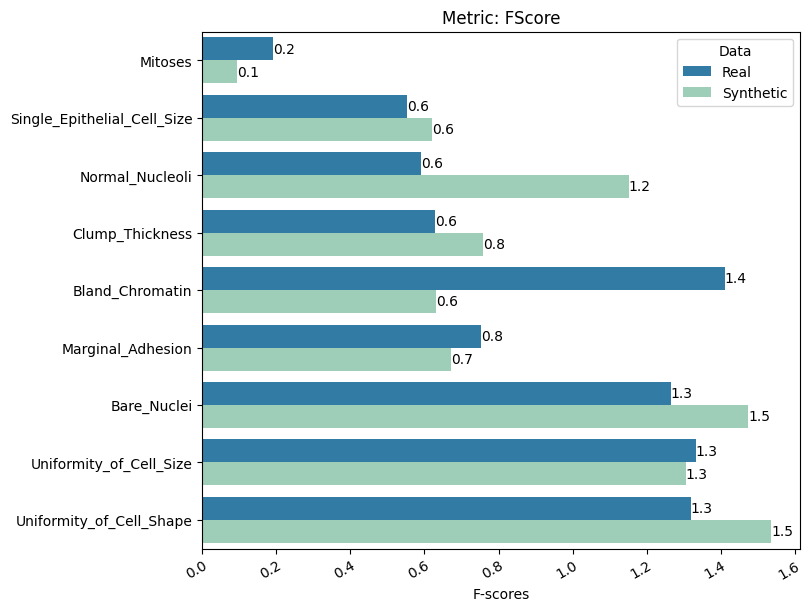

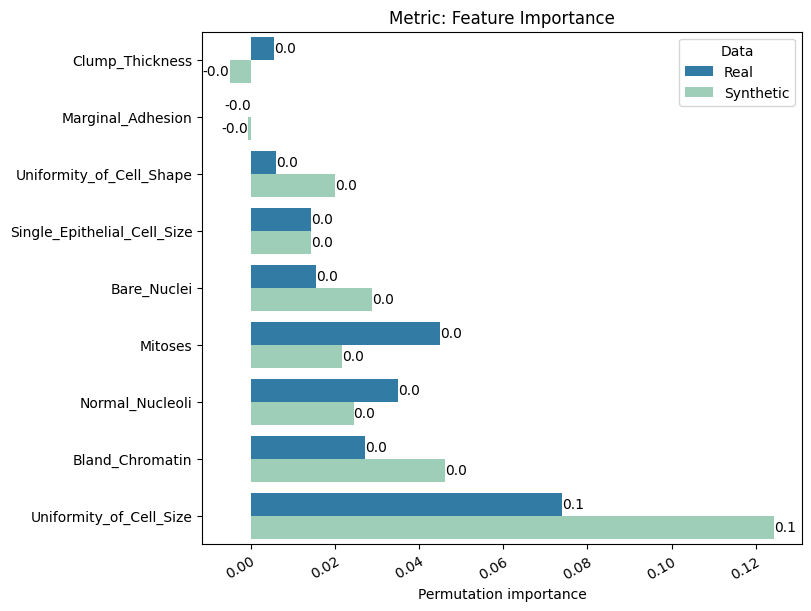

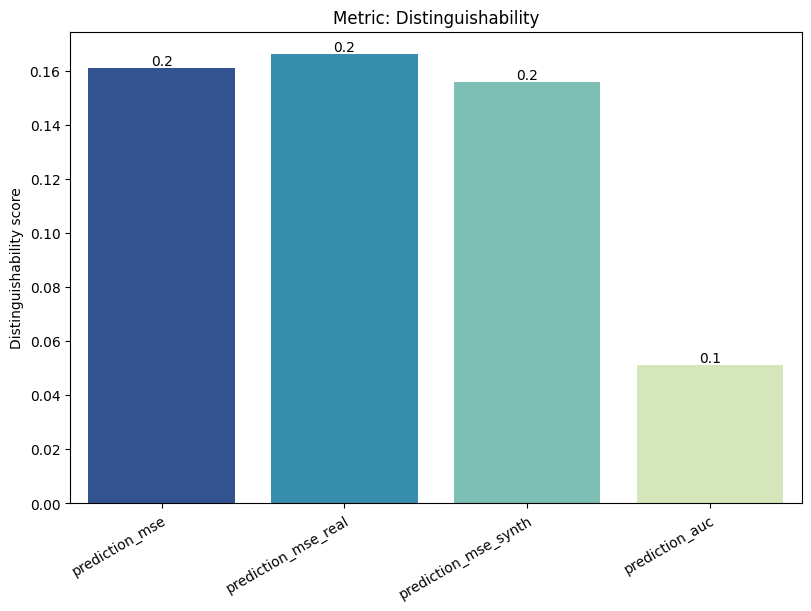

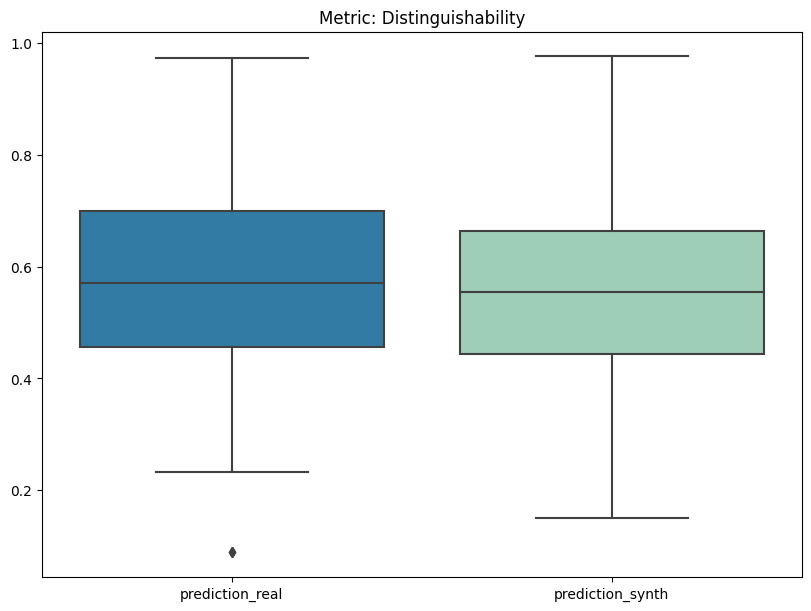

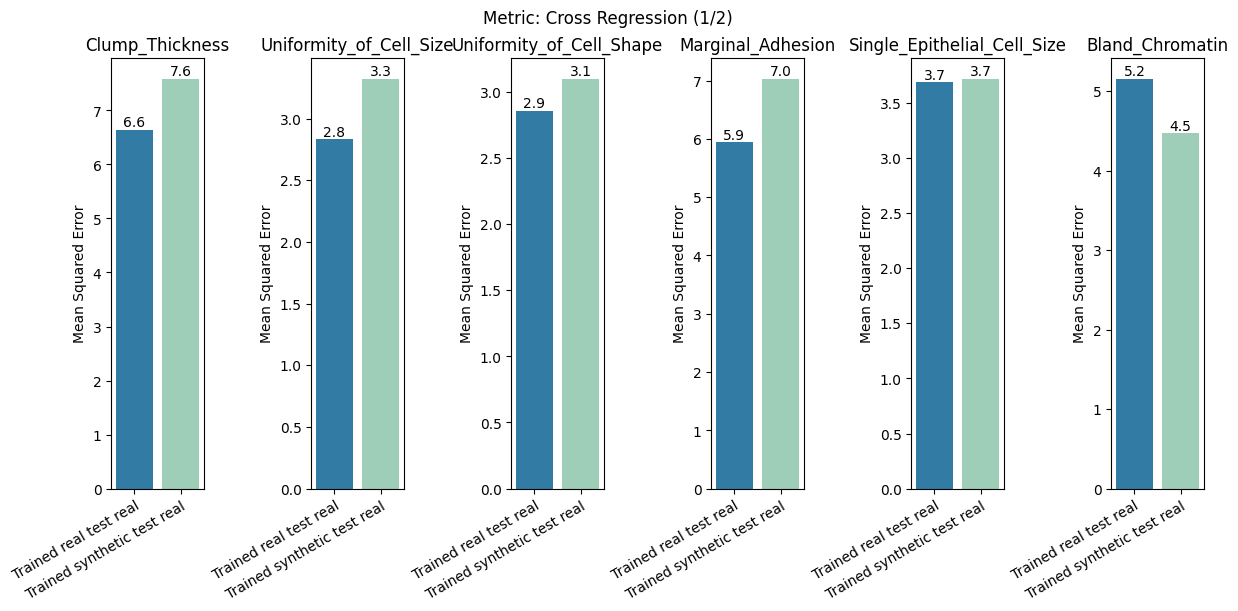

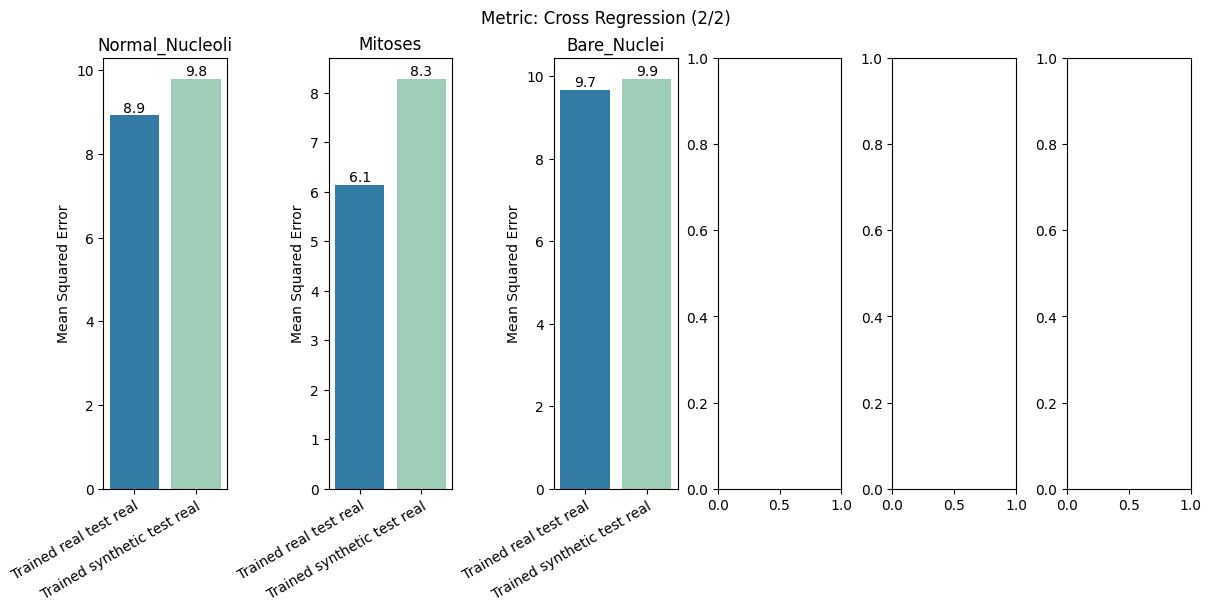

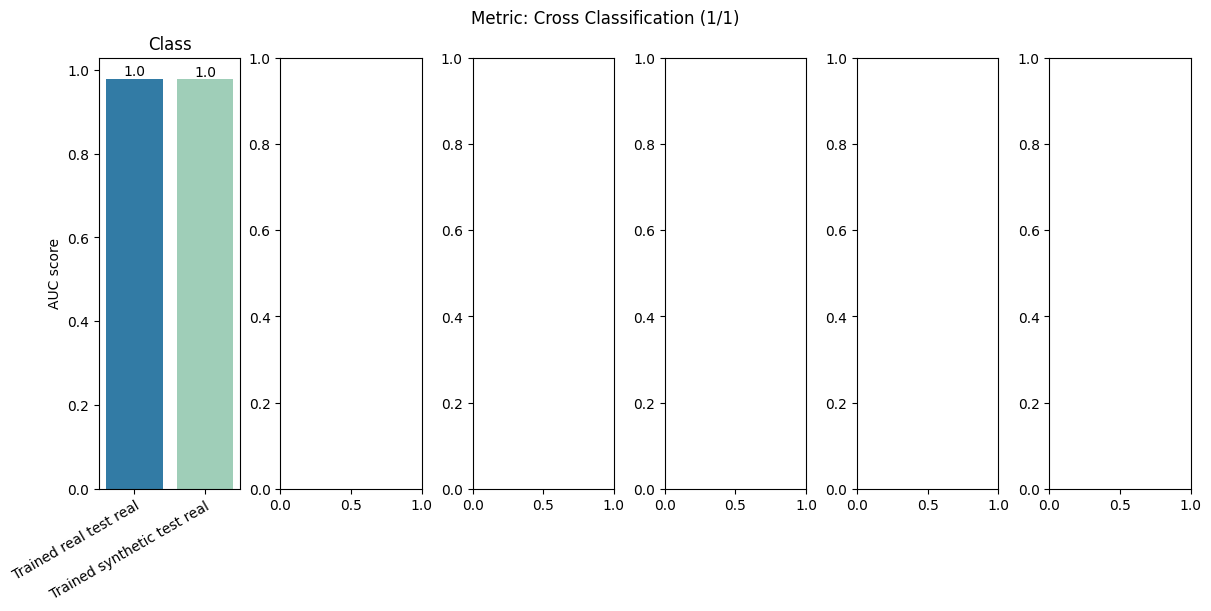

In [11]:
report.detailed(show=True, save_folder=None, figure_format="png")

#### To display only one metric, the draw function can be used.

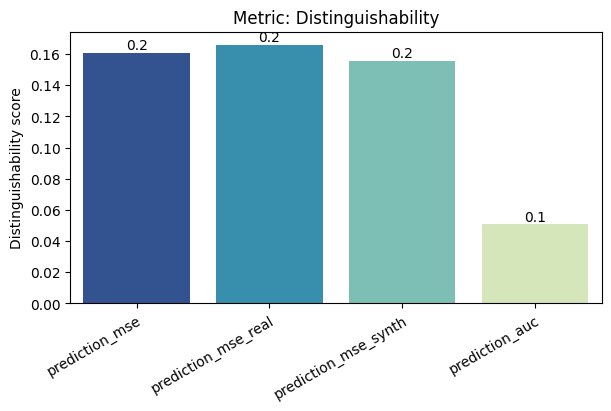

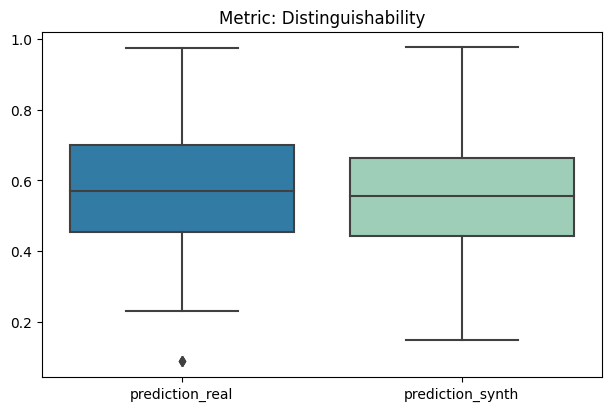

In [12]:
report.draw(
    metric_name="Distinguishability",
    figsize=(
        6,
        4,
    ),  # Reset here the size of the figure if it was too small in the report
    show=True,
    save_folder=None,
    figure_format="png",
)

### Second option: Create and compute the report for a subset of metrics only

#### Here only compute the Distinguishability metric

In [13]:
report = Report(
    dataset_name="Wisconsin Breast Cancer Dataset",
    df_real=df_real,
    df_synthetic=df_synth,
    metadata=metadata,
    metrics=["Distinguishability"],  # the subset of metrics to compute
    num_repeat=3,
    use_gpu=False,  # if a GPU is available, it will accelerate the computation
    alpha=0.05,
)

In [14]:
report.compute()

In [15]:
report.summary()

,name,submetric,value,objective,min,max
0,Distinguishability,prediction_mse,0.143709,min,0,1
1,Distinguishability,prediction_mse_real,0.151601,min,0,1
2,Distinguishability,prediction_mse_synth,0.135817,min,0,1
3,Distinguishability,prediction_auc,0.029753,min,0,1


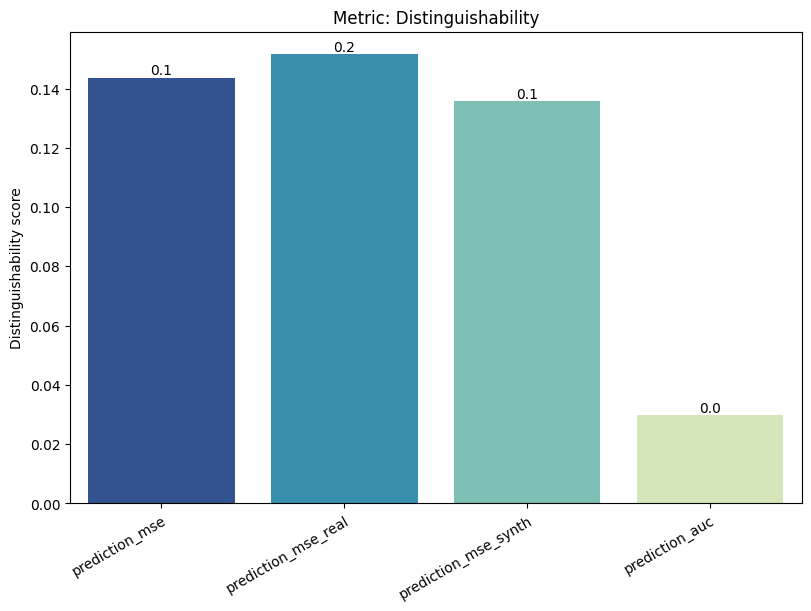

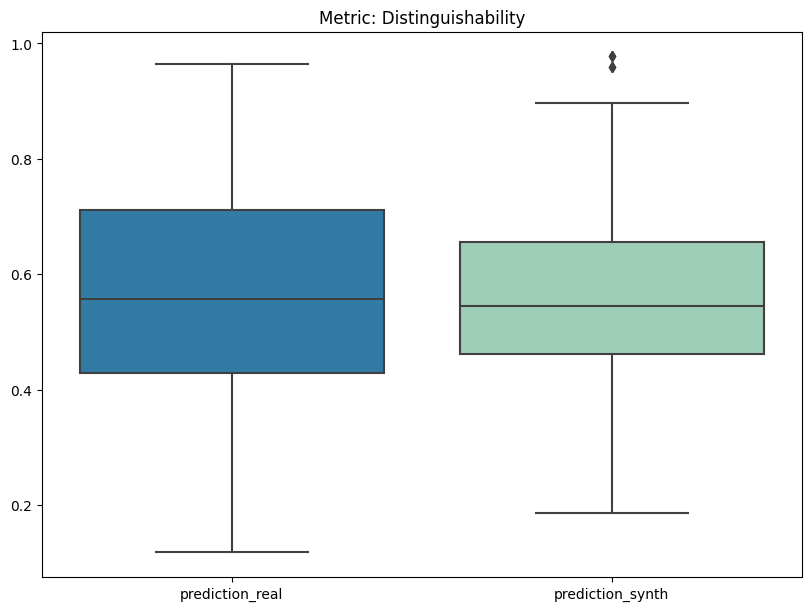

In [16]:
report.detailed(show=True, save_folder=None, figure_format="png")